In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
mmd_regret_path="results/tpcds/mmd_regret_batch.csv"
regret_df = pd.read_csv(mmd_regret_path)

In [6]:
regret_df["batch_gap"] = regret_df["test_batch"] - regret_df["train_batch"]
regret_df["abs_batch_gap"] = regret_df["batch_gap"].abs()
regret_df["future_batch"] = regret_df["test_batch"] > regret_df["train_batch"]

In [7]:
def plot_mmd_vs_regret(batch_df, save_path=None):
    plt.figure(figsize=(7, 5))

    plt.scatter(
        batch_df["mmd_score"],
        batch_df["mean_regret"],
        alpha=0.7
    )

    plt.xlabel("MMD Score")
    plt.ylabel("Mean Regret")
    plt.title("MMD Score vs Mean Regret")

    # correlation
    corr = batch_df["mmd_score"].corr(batch_df["mean_regret"])
    plt.text(
        0.05,
        0.95,
        f"Pearson r = {corr:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

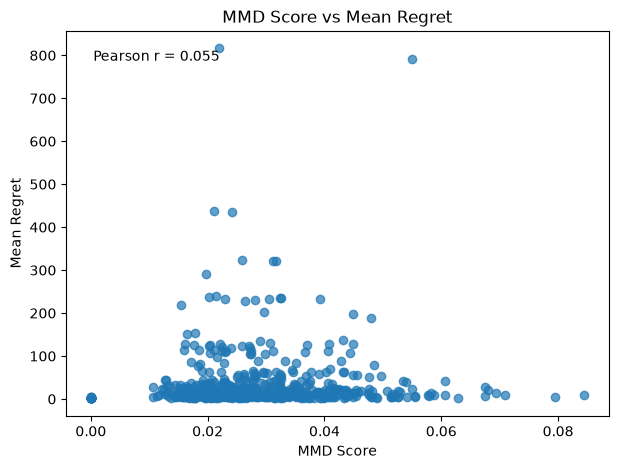

In [8]:
plot_mmd_vs_regret(
    regret_df,
    "results/tpcds/mmd_vs_mean_regret.png"
)

In [9]:
def plot_mmd_vs_log_regret(batch_df, save_path=None):
    df = batch_df.copy()
    df["log_mean_regret"] = np.log1p(df["mean_regret"])

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df["mmd_score"],
        df["log_mean_regret"],
        alpha=0.7
    )

    plt.xlabel("MMD Score")
    plt.ylabel("log(1 + Mean Regret)")
    plt.title("MMD Score vs Log Mean Regret")

    corr = df["mmd_score"].corr(df["log_mean_regret"])
    plt.text(
        0.05,
        0.95,
        f"Pearson r = {corr:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

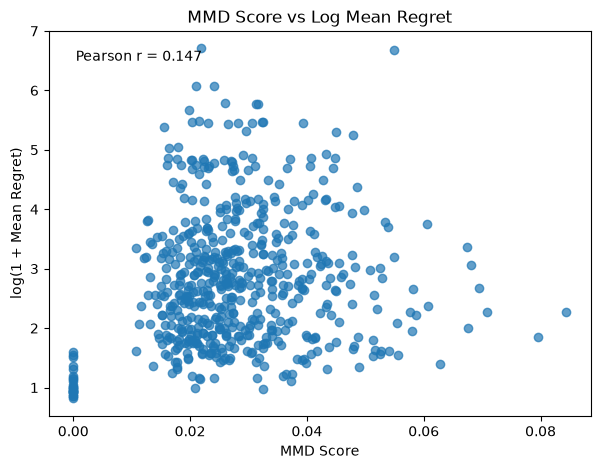

In [10]:
plot_mmd_vs_log_regret(
    regret_df,
    "results/tpcds/mmd_vs_log_mean_regret.png"
)

In [11]:
def plot_gap_vs_metrics(batch_df, save_path=None):
    gap_df = (
        batch_df
        .groupby("abs_batch_gap")
        .agg(
            mean_mmd_score=("mmd_score", "mean"),
            mean_regret=("mean_regret", "mean"),
            median_regret=("median_regret", "mean")
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(7, 5))

    ax1.plot(
        gap_df["abs_batch_gap"],
        gap_df["mean_mmd_score"],
        marker="o",
        label="Mean MMD Score"
    )
    ax1.set_xlabel("Absolute Batch Gap")
    ax1.set_ylabel("Mean MMD Score")

    ax2 = ax1.twinx()
    ax2.plot(
        gap_df["abs_batch_gap"],
        gap_df["mean_regret"],
        marker="s",
        label="Mean Regret"
    )
    ax2.set_ylabel("Mean Regret")

    plt.title("Batch Gap vs MMD Score / Regret")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return gap_df

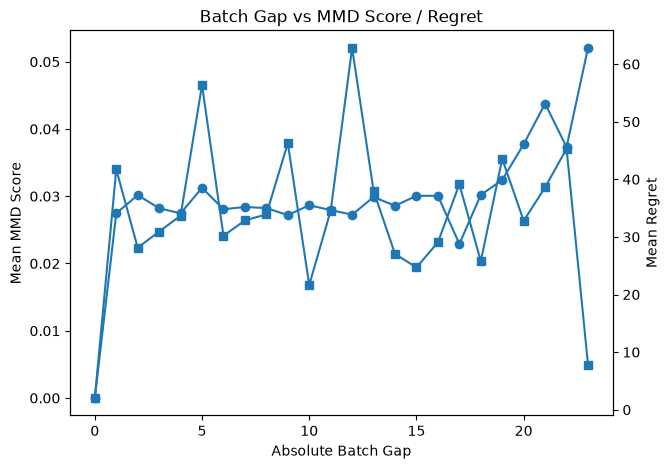

,abs_batch_gap,mean_mmd_score,mean_regret,median_regret
0,0,0.000000,2.036440,1.160667
1,1,0.027463,41.725996,1.331292
2,2,0.030170,28.135485,1.324614
3,3,0.028220,30.933033,1.338616
4,4,0.027456,33.693204,1.318999
5,5,0.031256,56.370625,1.317014
6,6,0.028062,30.198551,1.319082
7,7,0.028406,32.860142,1.323330
8,8,0.028240,33.920325,1.333986
9,9,0.027195,46.274636,1.313379


In [12]:
gap_df = plot_gap_vs_metrics(
    regret_df,
    "results/tpcds/batch_gap_vs_mmd_regret.png"
)

gap_df

In [13]:
corr_df = regret_df[
    [
        "mmd_score",
        "mean_regret",
        "median_regret",
        "max_regret",
        "batch_gap",
        "abs_batch_gap"
    ]
].corr()

corr_df

,mmd_score,mean_regret,median_regret,max_regret,batch_gap,abs_batch_gap
mmd_score,1.000000,0.055491,0.110004,0.037785,-6.757468e-02,2.174185e-01
mean_regret,0.055491,1.000000,0.016661,0.990027,-1.493504e-02,2.072977e-02
median_regret,0.110004,0.016661,1.000000,0.015885,1.194829e-01,4.138711e-02
max_regret,0.037785,0.990027,0.015885,1.000000,-2.480531e-02,1.085346e-02
batch_gap,-0.067575,-0.014935,0.119483,-0.024805,1.000000e+00,1.933415e-17
abs_batch_gap,0.217418,0.020730,0.041387,0.010853,1.933415e-17,1.000000e+00


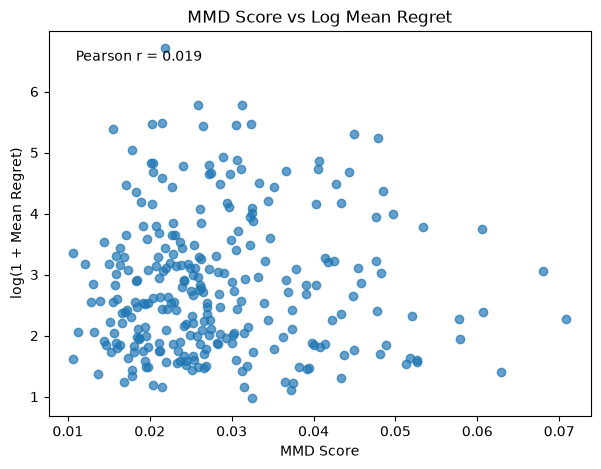

In [15]:
df_cross = regret_df[regret_df["same_batch"] == False].copy()
df_cross["log_mean_regret"] = np.log1p(df_cross["mean_regret"])

# plot_mmd_vs_log_regret(df_cross)
df_future = regret_df[regret_df["test_batch"] > regret_df["train_batch"]].copy()
df_future["log_mean_regret"] = np.log1p(df_future["mean_regret"])

plot_mmd_vs_log_regret(df_future)